In [1]:
## Cell 1 — Install & Import Dependencies
#!pip install yfinance pandas numpy matplotlib scikit-learn tensorflow -q

In [2]:
# Cell 2 — Imports
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Cell 3 — Fetch Stock Data (MSFT & NVDA from 2015 onwards)
import yfinance as yf

tickers = ["MSFT", "NVDA"]
raw_data = {}

for ticker in tickers:
    df = yf.download(ticker, start="2015-01-01", interval="1d", auto_adjust=True, progress=False)
    
    # Check if we actually got data
    if not df.empty:
        raw_data[ticker] = df
        print(f"{ticker}: {len(df)} trading days fetched | {df.index[0].date()} → {df.index[-1].date()}")
    else:
        print(f"Warning: No data found for {ticker}. Check your connection or ticker symbol.")

MSFT: 2834 trading days fetched | 2015-01-02 → 2026-04-10
NVDA: 2834 trading days fetched | 2015-01-02 → 2026-04-10


In [4]:
# Cell 4 — Preview & Validate Data
for ticker, df in raw_data.items():
    print(f"\n{'='*40}")
    print(f"  {ticker} — Head")
    print(f"{'='*40}")
    display(df.head())
    print(f"\nMissing values:\n{df.isnull().sum()}")
    print(f"\nPrice range: ${df['Open'].min():.2f} → ${df['Open'].max():.2f}")


  MSFT — Head


Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2015-01-02,39.767689,40.328995,39.580589,39.682644,27913900
2015-01-05,39.401989,39.742173,39.333950,39.436005,39673900
2015-01-06,38.823662,39.759170,38.730110,39.444500,36447900
2015-01-07,39.316936,39.512543,38.687595,39.104321,29114100
2015-01-08,40.473576,40.609650,39.733673,39.759186,29645200



Missing values:
Price   Ticker
Close   MSFT      0
High    MSFT      0
Low     MSFT      0
Open    MSFT      0
Volume  MSFT      0
dtype: int64


TypeError: unsupported format string passed to Series.__format__

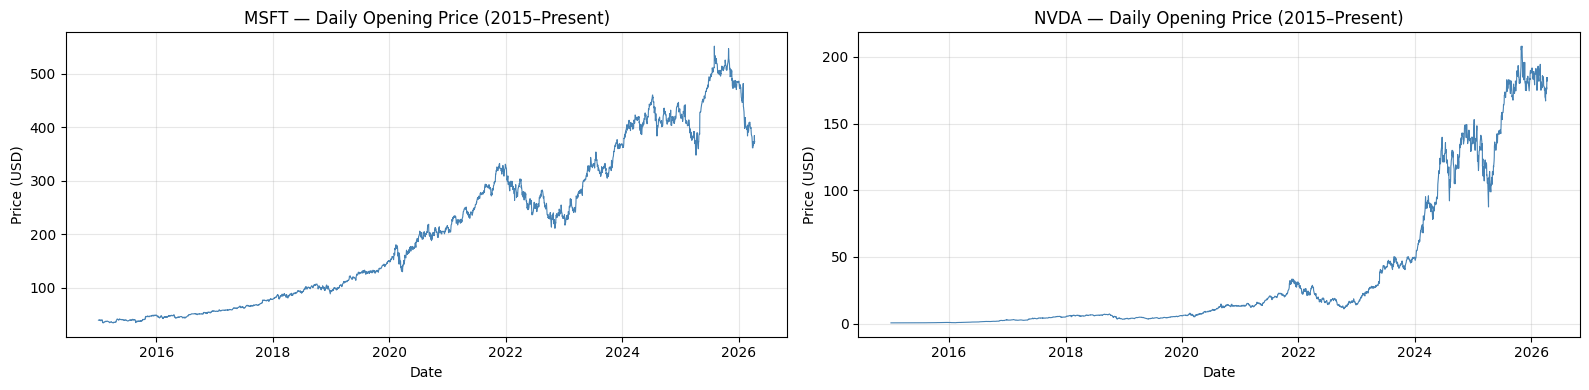

In [5]:
# Cell 5 — Plot Raw Opening Prices
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, (ticker, df) in zip(axes, raw_data.items()):
    ax.plot(df.index, df['Open'], color='steelblue', linewidth=0.8)
    ax.set_title(f"{ticker} — Daily Opening Price (2015–Present)", fontsize=12)
    ax.set_xlabel("Date")
    ax.set_ylabel("Price (USD)")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# Cell 6 — Extract Opening Prices & Scale
LOOK_BACK = 50  # number of past days the model looks at (matches paper)

scaled_data = {}
scalers = {}

for ticker, df in raw_data.items():
    prices = df['Open'].values.reshape(-1, 1)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled = scaler.fit_transform(prices)
    scaled_data[ticker] = scaled
    scalers[ticker] = scaler
    print(f"{ticker}: scaled to [0,1] | shape: {scaled.shape}")

MSFT: scaled to [0,1] | shape: (2834, 1)
NVDA: scaled to [0,1] | shape: (2834, 1)


In [7]:
# Cell 7 — Create Sequences & Train/Test Split (80/20)
def create_sequences(data, look_back=50):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i-look_back:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

sequences = {}

for ticker, scaled in scaled_data.items():
    split = int(len(scaled) * 0.80)

    train = scaled[:split]
    test  = scaled[split - LOOK_BACK:]   # step back LOOK_BACK so test sequences are complete

    X_train, y_train = create_sequences(train, LOOK_BACK)
    X_test,  y_test  = create_sequences(test,  LOOK_BACK)

    # Reshape to (samples, timesteps, features) — required by Keras LSTM
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)

    sequences[ticker] = {
        'X_train': X_train, 'y_train': y_train,
        'X_test':  X_test,  'y_test':  y_test,
        'split':   split
    }
    print(f"{ticker} | Train: {X_train.shape} → {y_train.shape} | Test: {X_test.shape} → {y_test.shape}")

MSFT | Train: (2217, 50, 1) → (2217,) | Test: (567, 50, 1) → (567,)
NVDA | Train: (2217, 50, 1) → (2217,) | Test: (567, 50, 1) → (567,)


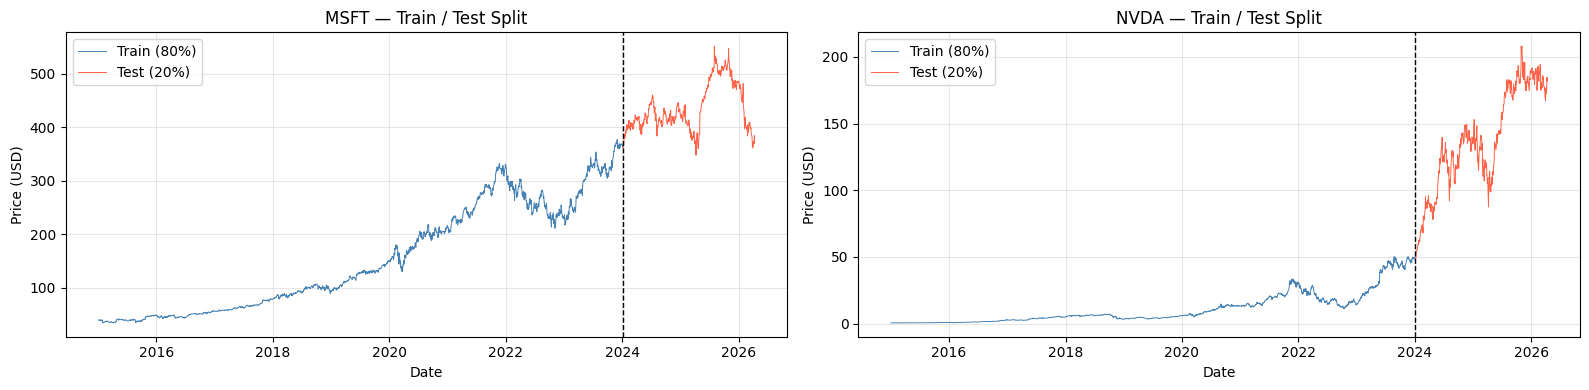

In [8]:
# Cell 8 — Sanity Check: Plot Train/Test Split
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, (ticker, df) in zip(axes, raw_data.items()):
    split = sequences[ticker]['split']
    ax.plot(df.index[:split], df['Open'].values[:split], color='steelblue', linewidth=0.7, label='Train (80%)')
    ax.plot(df.index[split:], df['Open'].values[split:], color='tomato',    linewidth=0.7, label='Test (20%)')
    ax.axvline(df.index[split], color='black', linestyle='--', linewidth=1)
    ax.set_title(f"{ticker} — Train / Test Split", fontsize=12)
    ax.set_xlabel("Date")
    ax.set_ylabel("Price (USD)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Cell 9 — Build LSTM Model (matches paper architecture exactly)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
import tensorflow as tf

tf.random.set_seed(42)

def build_model(look_back=50):
    model = Sequential([
        LSTM(96, return_sequences=True, input_shape=(look_back, 1)),
        Dropout(0.2),
        LSTM(96, return_sequences=True),
        Dropout(0.2),
        LSTM(96, return_sequences=True),
        Dropout(0.2),
        LSTM(96, return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

model = build_model(LOOK_BACK)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50, 96)              │          37,632 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 50, 96)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 50, 96)              │          74,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50, 96)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 50, 96)              │          74,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 50, 96)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 96)                  │          74,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 96)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              97 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 260,065 (1015.88 KB)

 Trainable params: 260,065 (1015.88 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Cell 10 — Verify Parameter Count (should match paper: 260,065 total)
total     = model.count_params()
trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)

print(f"Total parameters     : {total:,}")
print(f"Trainable parameters : {trainable:,}")
print(f"Non-trainable        : {total - trainable:,}")
print(f"\nMatches paper (260,065): {'✅' if total == 260065 else '❌'} — got {total:,}")

Total parameters     : 260,065
Trainable parameters : 260,065
Non-trainable        : 0

Matches paper (260,065): ✅ — got 260,065


In [11]:
# Cell 11 — Train Model for All Epoch Variants (12, 25, 50, 100)
import time

EPOCHS_LIST = [12, 25, 50, 100]
trained_models = {}

for ticker in ["MSFT", "NVDA"]:
    trained_models[ticker] = {}
    X_train = sequences[ticker]['X_train']
    y_train = sequences[ticker]['y_train']

    for epochs in EPOCHS_LIST:
        model = build_model(LOOK_BACK)
        t0 = time.time()
        history = model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=32,
            verbose=0
        )
        elapsed = time.time() - t0
        trained_models[ticker][epochs] = {
            'model':   model,
            'history': history,
            'time':    elapsed,
            'loss':    history.history['loss'][-1]
        }
        print(f"{ticker} | {epochs:>3} epochs | loss: {history.history['loss'][-1]:.4e} | time: {elapsed:.0f}s")

MSFT |  12 epochs | loss: 8.5217e-04 | time: 84s
MSFT |  25 epochs | loss: 5.8039e-04 | time: 154s
MSFT |  50 epochs | loss: 3.3913e-04 | time: 286s
MSFT | 100 epochs | loss: 2.7866e-04 | time: 569s
NVDA |  12 epochs | loss: 7.8092e-05 | time: 72s
NVDA |  25 epochs | loss: 5.4558e-05 | time: 150s
NVDA |  50 epochs | loss: 4.7344e-05 | time: 296s
NVDA | 100 epochs | loss: 3.7805e-05 | time: 581s


In [12]:
# Cell 12 — Generate Predictions for All Models
predictions = {}

for ticker in ["MSFT", "NVDA"]:
    predictions[ticker] = {}
    X_test  = sequences[ticker]['X_test']
    y_test  = sequences[ticker]['y_test']
    scaler  = scalers[ticker]

    for epochs in EPOCHS_LIST:
        model = trained_models[ticker][epochs]['model']

        pred_scaled = model.predict(X_test, verbose=0)
        pred_prices = scaler.inverse_transform(pred_scaled)
        real_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

        predictions[ticker][epochs] = {
            'real': real_prices,
            'pred': pred_prices,
        }

In [13]:
# Cell 13 — Evaluation Metrics (replicates Table 2 from paper)
from sklearn.metrics import mean_squared_error, mean_absolute_error

print(f"\n{'='*75}")
print(f"{'':20} {'MSFT':^25} {'NVDA':^25}")
print(f"{'Epochs':<10} {'Time(s)':>7} {'Loss':>10} {'RMSE':>8}   {'Time(s)':>7} {'Loss':>10} {'RMSE':>8}")
print(f"{'-'*75}")

for epochs in EPOCHS_LIST:
    row = f"{epochs:<10}"
    for ticker in ["MSFT", "NVDA"]:
        t    = trained_models[ticker][epochs]['time']
        loss = trained_models[ticker][epochs]['loss']
        real = predictions[ticker][epochs]['real']
        pred = predictions[ticker][epochs]['pred']
        rmse = np.sqrt(mean_squared_error(real, pred))
        mae  = mean_absolute_error(real, pred)
        row += f" {t:>7.0f} {loss:>10.4e} {rmse:>8.2f}  "
    print(row)

print(f"{'='*75}")


                               MSFT                      NVDA           
Epochs     Time(s)       Loss     RMSE   Time(s)       Loss     RMSE
---------------------------------------------------------------------------
12              84 8.5217e-04    23.69        72 7.8092e-05    23.25  
25             154 5.8039e-04    13.77       150 5.4558e-05    18.57  
50             286 3.3913e-04    11.94       296 4.7344e-05    10.62  
100            569 2.7866e-04    15.08       581 3.7805e-05    22.66  


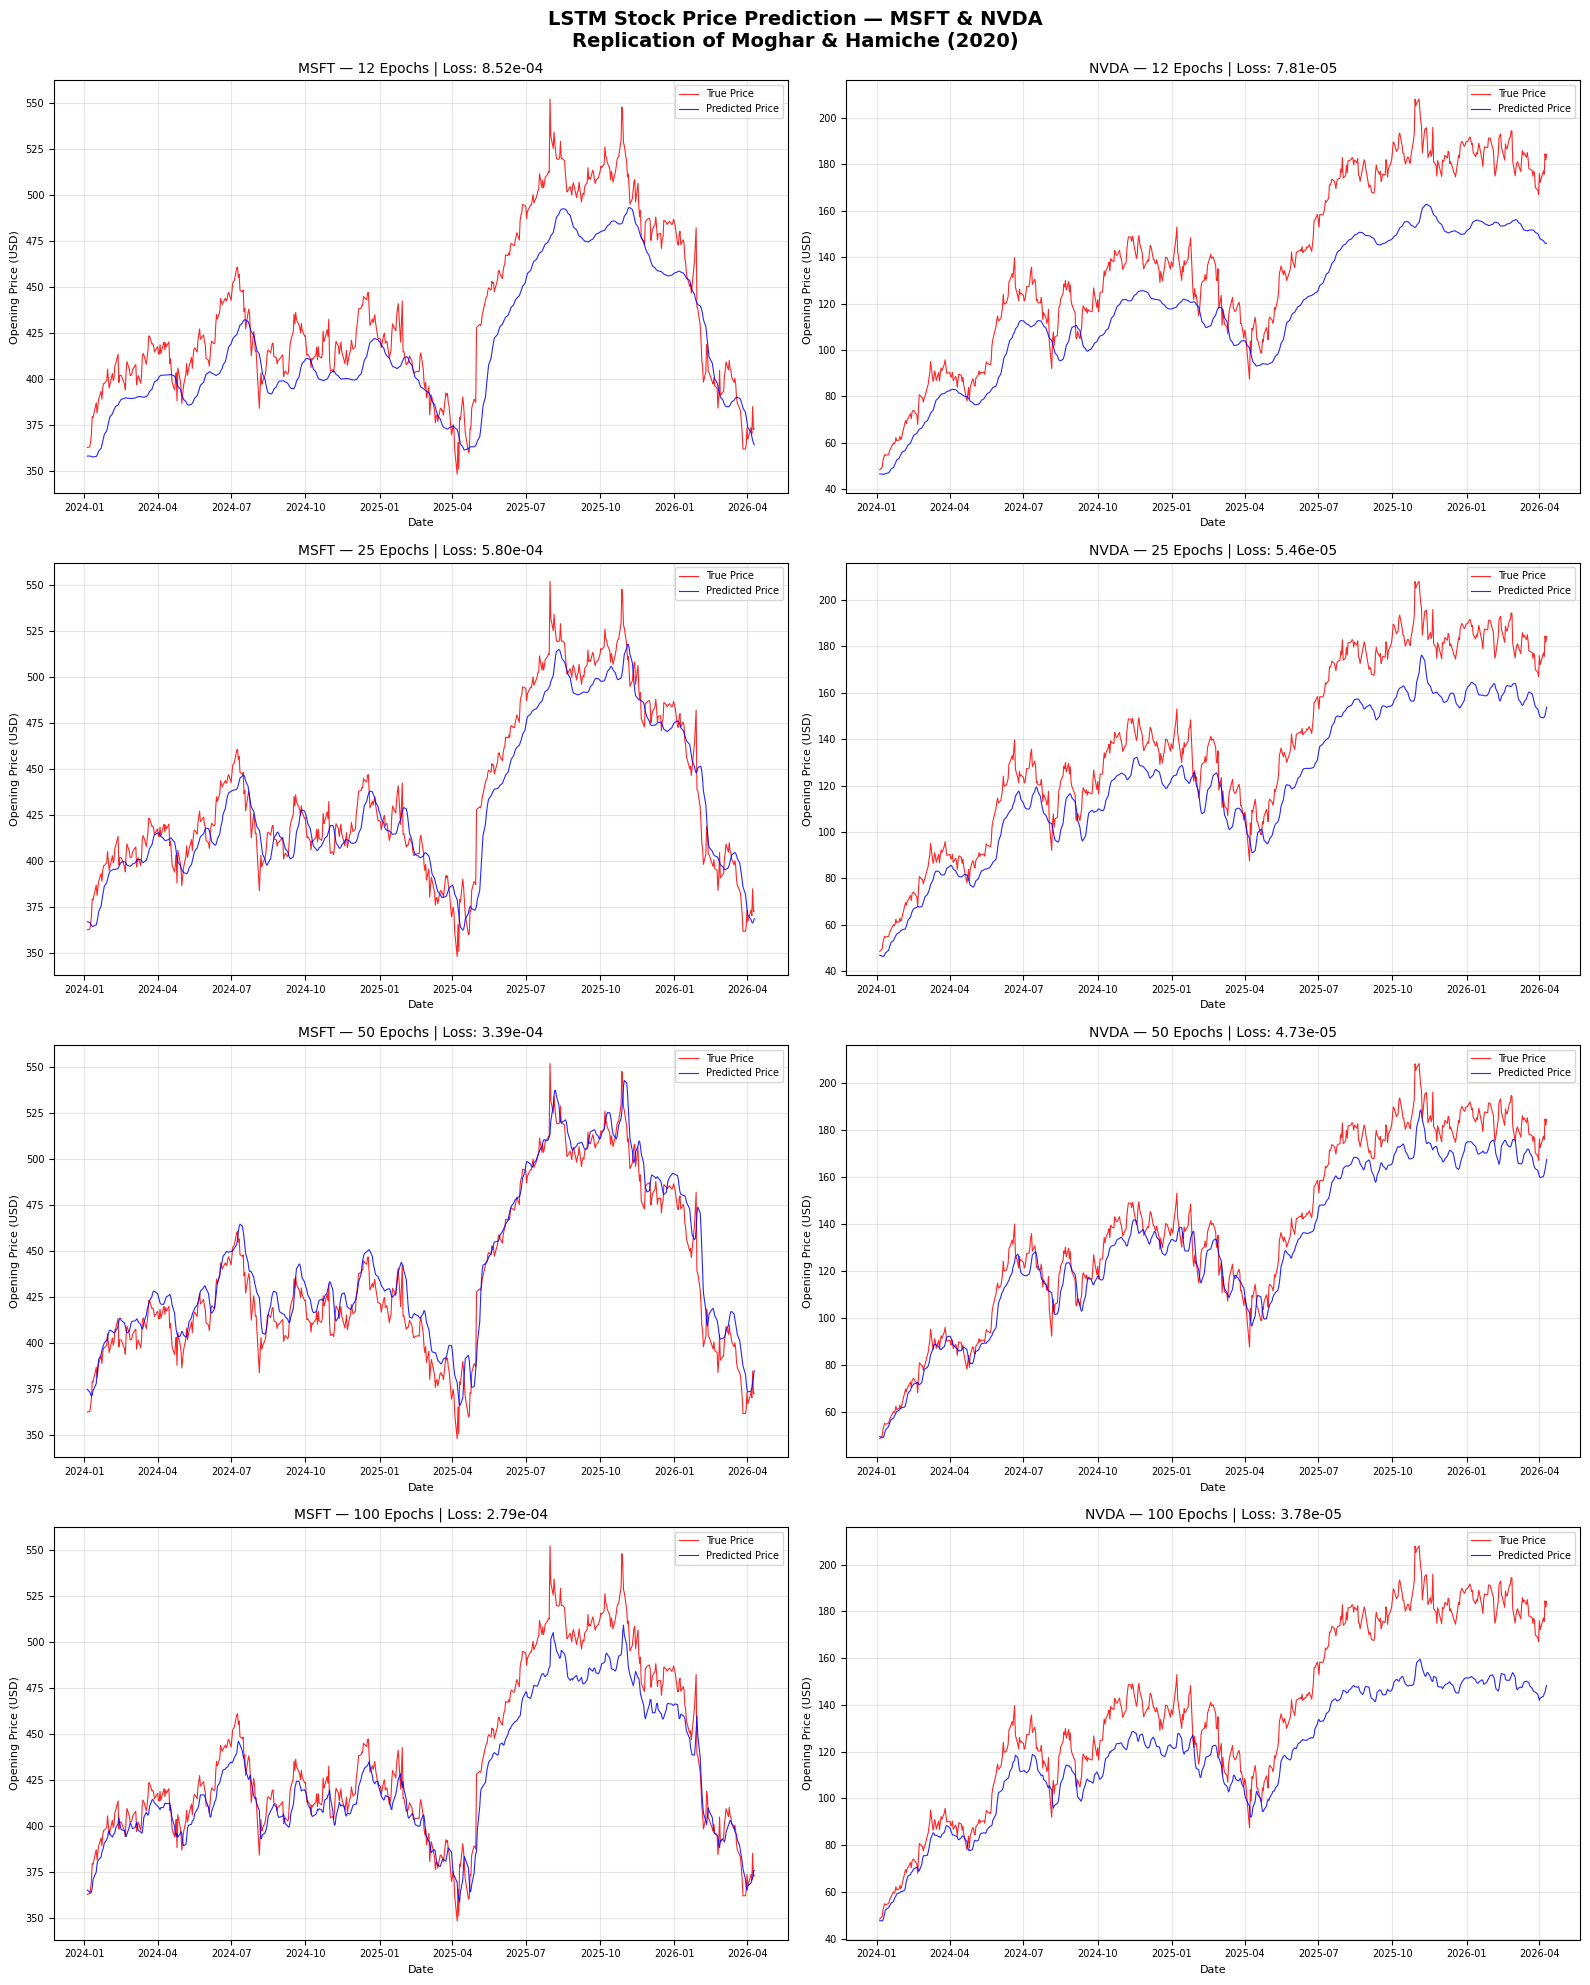

In [14]:
# Cell 14 — Plot Results Grid (replicates Figure 4 from paper)
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
fig.suptitle("LSTM Stock Price Prediction — MSFT & NVDA\nReplication of Moghar & Hamiche (2020)",
             fontsize=14, fontweight='bold', y=0.99)

for row, epochs in enumerate(EPOCHS_LIST):
    for col, ticker in enumerate(["MSFT", "NVDA"]):
        ax    = axes[row, col]
        real  = predictions[ticker][epochs]['real'].flatten()
        pred  = predictions[ticker][epochs]['pred'].flatten()
        loss  = trained_models[ticker][epochs]['loss']
        split = sequences[ticker]['split']
        dates = raw_data[ticker].index[split:]

        ax.plot(dates, real, color='red',  linewidth=0.8, label='True Price',      alpha=0.85)
        ax.plot(dates, pred, color='blue', linewidth=0.8, label='Predicted Price',  alpha=0.85)
        ax.set_title(f"{ticker} — {epochs} Epochs | Loss: {loss:.2e}", fontsize=10)
        ax.set_xlabel("Date", fontsize=8)
        ax.set_ylabel("Opening Price (USD)", fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()